In [1]:
"""
    given fp16 model, sample image, and bboxes
    confirm token strings look okay 
    min depth values are populated for the ewtracted tokens and strings

    plan
    - load sample images
    - load model
    - draw bboxes on image
        - on relevant patches
    - run model
    - get nearest token strings
    - get depth values
    - sanity check both the results


"""

import csv
import json
import random
import subprocess
import sys
from pathlib import Path

import requests
from PIL import Image
import datasets
import numpy as np
import torch
from io import BytesIO
from matplotlib import pyplot as plt
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration


# load images
num_images = 5
FIXED_RESOLUTION = 448  # → 16×16 merged token grid (256 visual tokens)
seed = 42
_HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"}

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed = 42
seed_all(seed)

In [2]:
model_dir = Path("/workspace/latentlens/experiment/data/Qwen2-VL-7B-Instruct")
index_dir = Path("/workspace/latentlens/experiment/data/latentlens-qwen2vl-embeddings")
data_dir = Path("/workspace/latentlens/experiment/data/pixmo_cap")



def load_images(data_dir: Path, num_images = 5):

    def _fetch_image(url: str) -> Image.Image:
        r = requests.get(url, stream=True, timeout=10, headers=_HEADERS)
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert("RGB")

    ds = datasets.load_from_disk(data_dir)['validation']
    results = []
    idx = 0
    while len(results) < num_images and idx < len(ds):
        row = ds[idx]
        try:
            image = _fetch_image(row["image_url"])
            results.append({
                "idx": idx,
                "image_url": row["image_url"],
                "image": image,
                "caption": row["caption"],
            })
            print(f"  [{len(results)}/{num_images}] val_idx={idx} — {row['image_url'][:70]}")
        except Exception as e:
            print(f"  Skipped val_idx={idx}: {e}")
        idx += 1
    return results

def show_image(image: Image.Image):
    plt.imshow(image)
    plt.axis("off")
    plt.show()


images = load_images(data_dir)

  [1/5] val_idx=0 — https://img.freepik.com/premium-photo/red-kidney-bean-is-variety-commo
  [2/5] val_idx=1 — https://i.redd.it/hvxnfy7wuwxc1.png
  [3/5] val_idx=2 — http://i.imgur.com/doSWm.png
  [4/5] val_idx=3 — https://1.bp.blogspot.com/-qy9fh1m70Fk/WhH5wf-AgnI/AAAAAAAAlrY/fxf3N2F
  [5/5] val_idx=4 — https://techcult.com/wp-content/uploads/2021/07/Tap-on-the-three-dots-


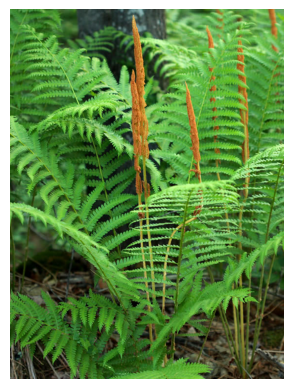

In [3]:
show_image(images[3]["image"])

In [4]:
# load model
def load_model(model_dir: Path):
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        str(model_dir), torch_dtype=torch.float16, device_map="auto"
    )

    model.eval()

    processor = AutoProcessor.from_pretrained(str(model_dir))
    px = FIXED_RESOLUTION * FIXED_RESOLUTION
    processor.image_processor.min_pixels = px
    processor.image_processor.max_pixels = px
    processor.image_processor.do_resize = False

    print(f"  Loaded model on {model.device}, resolution locked to {FIXED_RESOLUTION}×{FIXED_RESOLUTION}")
    return model, processor


model, processor,= load_model(model_dir)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


  Loaded model on cuda:0, resolution locked to 448×448


In [8]:
processor.image_processor.merge_size

2

In [10]:
# draw bboxes on image
from PIL import ImageDraw

IMAGE_PAD_TOKEN_ID = 151655  # <|image_pad|> in Qwen2-VL vocabulary


def get_images_with_bboxes(images, processor, seed=42):

    def _center_crop_square(img: Image.Image) -> Image.Image:
        w, h = img.size
        s = min(w, h)
        return img.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))

    def draw_bboxes(record: dict, image_idx: int) -> dict:
        print(f"  Image {i + 1}/{len(images)} — val_idx={record['idx']}")
        print(f"image size - {record['image'].size}")

        processed = _center_crop_square(record["image"]).resize(
            (FIXED_RESOLUTION, FIXED_RESOLUTION), Image.LANCZOS
        )
        # 448, 448
        print(f"processed size - {processed.size}")

        # 448, 448 -> with each patch size of 14, 14, you'll have 28x28 = 784 patches
        inputs = processor(
            images=[processed],
            text="<|image_pad|>Describe this image.",
            return_tensors="pt",
        )
        print(f"image grid thw - {inputs['image_grid_thw']}")
        print(f"pixel values - {inputs['pixel_values'].shape}")

        # Derive merged token grid from image_grid_thw
        thw = inputs["image_grid_thw"]        # [1, 3]: (temporal, grid_h, grid_w)
        _, gh, gw = thw[0].tolist()
        merge_size = processor.image_processor.merge_size   # = 2
        H = int(gh) // merge_size
        W = int(gw) // merge_size
        merged_patch_px = FIXED_RESOLUTION // W             # = 28px per merged patch

        # Locate vision tokens
        input_ids = inputs["input_ids"][0]
        positions = (input_ids == IMAGE_PAD_TOKEN_ID).nonzero(as_tuple=True)[0]
        vision_start = int(positions[0])
        num_vision = len(positions)

        # Pick selected patch: random choice from top-10 highest-variance patches
        img_arr = np.array(processed)
        variances = [
            float(img_arr[r * merged_patch_px:(r + 1) * merged_patch_px,
                           c * merged_patch_px:(c + 1) * merged_patch_px].var())
            for r in range(H) for c in range(W)
        ]
        top10_indices = sorted(range(H * W), key=lambda i: variances[i], reverse=True)[:10]
        selected_patch = random.Random(seed + image_idx).choice(top10_indices)

        # Draw all top-10 patches (blue), highlight selected patch (red)
        overlay = processed.copy()
        draw = ImageDraw.Draw(overlay)
        for patch_idx in top10_indices:
            row = patch_idx // W
            col = patch_idx % W
            x1, y1 = col * merged_patch_px, row * merged_patch_px
            x2, y2 = x1 + merged_patch_px, y1 + merged_patch_px
            color = "red" if patch_idx == selected_patch else "blue"
            width = 3 if patch_idx == selected_patch else 1
            draw.rectangle([x1, y1, x2, y2], outline=color, width=width)

        sel_row, sel_col = selected_patch // W, selected_patch % W
        bbox = [
            sel_col * merged_patch_px,
            sel_row * merged_patch_px,
            (sel_col + 1) * merged_patch_px,
            (sel_row + 1) * merged_patch_px,
        ]

        return {
            **record,
            "processed": processed,
            "image_with_bboxes": overlay,
            "patch_idx": selected_patch,
            "bbox": bbox,
            "grid": [H, W],
            "vision_start": vision_start,
            "num_vision": num_vision,
        }

    results = []
    for i, record in enumerate(images):
        print(f"  Image {i + 1}/{len(images)} — val_idx={record['idx']}")
        results.append(draw_bboxes(record, i))
    return results


images_with_bboxes = get_images_with_bboxes(images, processor)


  Image 1/5 — val_idx=0
  Image 1/5 — val_idx=0
image size - (626, 417)
processed size - (448, 448)
image grid thw - tensor([[ 1, 32, 32]])
pixel values - torch.Size([1024, 1176])
  Image 2/5 — val_idx=1
  Image 2/5 — val_idx=1
image size - (900, 799)
processed size - (448, 448)
image grid thw - tensor([[ 1, 32, 32]])
pixel values - torch.Size([1024, 1176])
  Image 3/5 — val_idx=2
  Image 3/5 — val_idx=2
image size - (636, 414)
processed size - (448, 448)
image grid thw - tensor([[ 1, 32, 32]])
pixel values - torch.Size([1024, 1176])
  Image 4/5 — val_idx=3
  Image 4/5 — val_idx=3
image size - (560, 756)
processed size - (448, 448)
image grid thw - tensor([[ 1, 32, 32]])
pixel values - torch.Size([1024, 1176])
  Image 5/5 — val_idx=4
  Image 5/5 — val_idx=4
image size - (540, 1170)
processed size - (448, 448)
image grid thw - tensor([[ 1, 32, 32]])
pixel values - torch.Size([1024, 1176])
